# KV Cache デモノートブック

`llm/kv_cache.md` の補足。GPU・大規模モデル不要で、numpy と標準ライブラリだけで動作する。

**目次**
1. KV Cache が必要な理由（Attention の基礎）
2. メモリサイズの計算
3. HuggingFace `DynamicCache` / `StaticCache` の動作シミュレーション
4. MHA / GQA / MQA のメモリ比較
5. PagedAttention ブロック管理シミュレーション
6. Prefix Caching ハッシュチェーン
7. KV Cache 量子化の効果

In [1]:
import numpy as np
import time
import hashlib
from dataclasses import dataclass, field
from typing import Optional
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print("imports OK")

imports OK


---
## 1. KV Cache が必要な理由

### 1-1. Scaled Dot-Product Attention の基礎

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right) V$$

Autoregressive デコードでは、ステップ $t$ に新しいトークン 1 個を生成するとき：
- $Q_t$：新トークン 1 個分（shape: `[1, d]`）
- $K_{0..t}$, $V_{0..t}$：過去全トークン分（shape: `[t+1, d]`）

**KV Cache なし** → $K$, $V$ を毎ステップ全トークン分再計算  
**KV Cache あり** → $K_t$, $V_t$ だけ新規計算し、キャッシュに追記

In [2]:
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def attention(Q, K, V):
    """Scaled Dot-Product Attention.  Q:[q,d]  K,V:[s,d]"""
    d = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d)   # [q, s]
    weights = softmax(scores)        # [q, s]
    return weights @ V               # [q, d]

# ---------- KV Cache なし ----------
def decode_without_cache(X, Wq, Wk, Wv, n_steps):
    """X: [context, d] の入力埋め込み。n_steps トークン生成"""
    tokens = X.copy()
    ops = 0
    for t in range(n_steps):
        Q = tokens[-1:] @ Wq          # 最新トークンだけ
        K = tokens @ Wk               # 毎回全トークン再計算
        V = tokens @ Wv               # 毎回全トークン再計算
        out = attention(Q, K, V)
        ops += len(tokens)             # K, V 再計算の行数
        new_token = out               # 簡略化：output をそのまま次の入力に
        tokens = np.vstack([tokens, new_token])
    return ops

# ---------- KV Cache あり ----------
def decode_with_cache(X, Wq, Wk, Wv, n_steps):
    """同じ処理をKVキャッシュで行う"""
    tokens = X.copy()
    K_cache = tokens @ Wk             # 初期コンテキスト分だけ事前計算
    V_cache = tokens @ Wv
    ops = 0
    for t in range(n_steps):
        new_token = tokens[-1:]
        Q   = new_token @ Wq
        K_t = new_token @ Wk          # 1 トークン分だけ計算
        V_t = new_token @ Wv
        K_cache = np.vstack([K_cache, K_t])   # キャッシュに追記
        V_cache = np.vstack([V_cache, V_t])
        out = attention(Q, K_cache, V_cache)
        ops += 1                       # K, V 計算は常に 1 行分
        tokens = np.vstack([tokens, out])
    return ops

# --- シミュレーション ---
np.random.seed(42)
d = 64
n_context = 32
n_steps   = 200
X  = np.random.randn(n_context, d)
Wq = np.random.randn(d, d) * 0.1
Wk = np.random.randn(d, d) * 0.1
Wv = np.random.randn(d, d) * 0.1

ops_no_cache = decode_without_cache(X, Wq, Wk, Wv, n_steps)
ops_cache    = decode_with_cache   (X, Wq, Wk, Wv, n_steps)

print(f"KV Cache なし: K/V 再計算行数の合計 = {ops_no_cache:,}")
print(f"KV Cache あり: K/V 再計算行数の合計 = {ops_cache:,}")
print(f"削減率: {(1 - ops_cache/ops_no_cache)*100:.1f}%")

KV Cache なし: K/V 再計算行数の合計 = 26,300
KV Cache あり: K/V 再計算行数の合計 = 200
削減率: 99.2%


/tmp/ipykernel_1700968/2345961554.py:23: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2345961554.py:23: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2345961554.py:23: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2345961554.py:23: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2345961554.py:23: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2345961554.py:23: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2345961554.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) mis

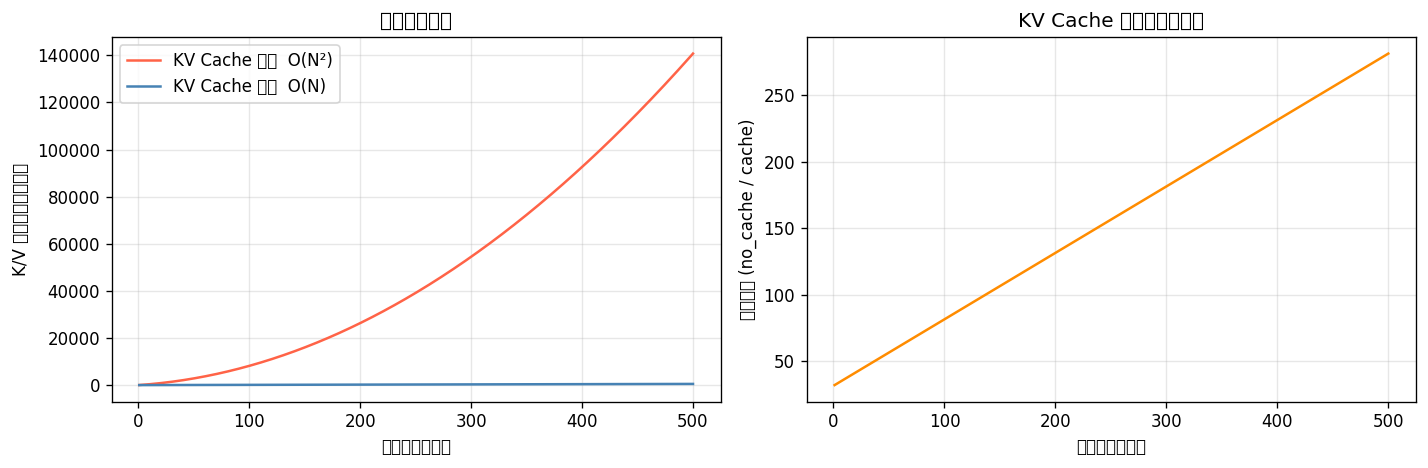

500 ステップ時の削減倍率: 282x


In [3]:
# KV Cache あり・なしの計算量を生成ステップ数ごとに可視化
steps_list = list(range(1, 501))
ops_no  = [sum(n_context + t for t in range(s)) for s in steps_list]
ops_yes = steps_list  # 毎ステップ 1 行分

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps_list, ops_no,  label="KV Cache なし  O(N²)", color="tomato")
axes[0].plot(steps_list, ops_yes, label="KV Cache あり  O(N)",  color="steelblue")
axes[0].set_xlabel("生成ステップ数")
axes[0].set_ylabel("K/V 再計算行数の累積")
axes[0].set_title("計算量の比較")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ratio = [no/yes for no, yes in zip(ops_no, ops_yes)]
axes[1].plot(steps_list, ratio, color="darkorange")
axes[1].set_xlabel("生成ステップ数")
axes[1].set_ylabel("削減倍率 (no_cache / cache)")
axes[1].set_title("KV Cache による削減倍率")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"500 ステップ時の削減倍率: {ratio[-1]:.0f}x")

---
## 2. メモリサイズの計算

1 レイヤーあたりの KV cache バイト数：

$$\text{bytes} = 2 \times \text{seq\_len} \times n_{kv\_heads} \times d_{head} \times \text{dtype\_bytes}$$

全レイヤー分 × バッチサイズ が実際のメモリ使用量になる。

In [4]:
def kv_cache_bytes(seq_len, num_kv_heads, head_dim, num_layers, dtype_bytes=2):
    """全レイヤーの KV cache サイズ (bytes)"""
    return 2 * seq_len * num_kv_heads * head_dim * num_layers * dtype_bytes

models = {
    "LLaMA-3 8B  (GQA)":  dict(num_kv_heads=8,  head_dim=128, num_layers=32),
    "LLaMA-3 70B (GQA)":  dict(num_kv_heads=8,  head_dim=128, num_layers=80),
    "LLaMA-2 7B  (MHA)":  dict(num_kv_heads=32, head_dim=128, num_layers=32),
    "Mistral 7B  (GQA)":  dict(num_kv_heads=8,  head_dim=128, num_layers=32),
    "GPT-2 Small (MHA)":  dict(num_kv_heads=12, head_dim=64,  num_layers=12),
}

seq_len    = 4096
batch_size = 8
dtype_bytes = 2  # bfloat16

print(f"{'モデル':<25} {'1 token (KB)':>12} {'4096 tokens (MB)':>18} "
      f"{'batch=8 (GB)':>14}")
print("-" * 72)
for name, cfg in models.items():
    per_token  = kv_cache_bytes(1,       **cfg, dtype_bytes=dtype_bytes)
    full_seq   = kv_cache_bytes(seq_len, **cfg, dtype_bytes=dtype_bytes)
    full_batch = full_seq * batch_size
    print(f"{name:<25} {per_token/1024:>12.1f} {full_seq/1024**2:>18.1f} "
          f"{full_batch/1024**3:>14.2f}")

モデル                       1 token (KB)   4096 tokens (MB)   batch=8 (GB)
------------------------------------------------------------------------
LLaMA-3 8B  (GQA)                128.0              512.0           4.00
LLaMA-3 70B (GQA)                320.0             1280.0          10.00
LLaMA-2 7B  (MHA)                512.0             2048.0          16.00
Mistral 7B  (GQA)                128.0              512.0           4.00
GPT-2 Small (MHA)                 36.0              144.0           1.12


---
## 3. HuggingFace DynamicCache / StaticCache 動作シミュレーション

transformers の `cache_utils.py` に実装された 2 種類のキャッシュ戦略：

| | DynamicCache | StaticCache |
|---|---|---|
| 実装 | `torch.cat` で毎ステップ再アロケーション | 事前確保済みテンソルにインデックス書き込み |
| メモリ | 必要な分だけ使う | max_seq_len 分を最初に確保 |
| torch.compile | 非対応（形状が変化する） | **対応**（形状固定） |
| 用途 | 開発・デバッグ | 本番推論（TorchScript, torch.compile） |

`DynamicLayer.update()` (transformers 実装の模倣)：
```python
self.key_cache[layer_idx] = torch.cat([self.key_cache[layer_idx], key_states], dim=-2)
```

`StaticLayer.update()` (transformers 実装の模倣)：
```python
k_out[..., cache_position, :] = key_states  # インデックス書き込み
```

/tmp/ipykernel_1700968/1378610575.py:59: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/1378610575.py:59: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/1378610575.py:59: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/1378610575.py:59: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/1378610575.py:59: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/1378610575.py:59: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/1378610575.py:59: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing

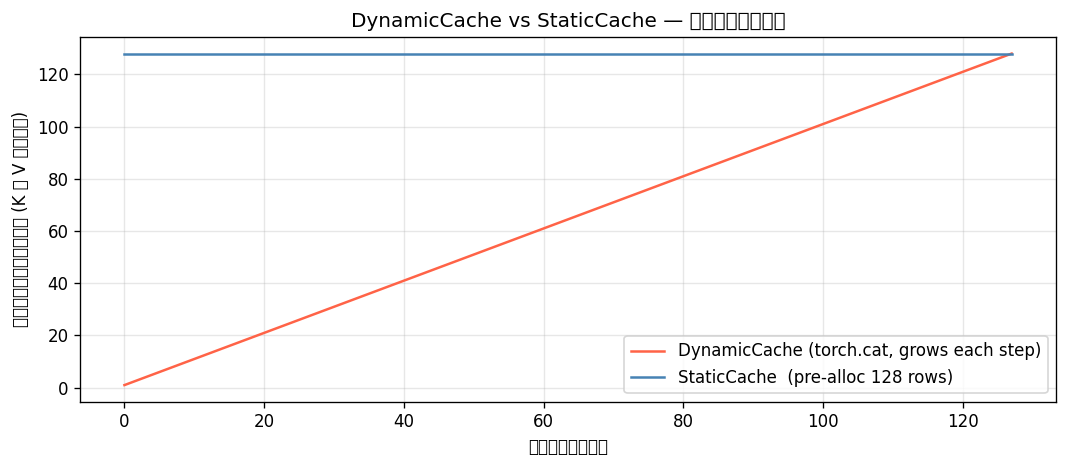

DynamicCache: 毎ステップ新配列生成 → torch.compile 不可だが無駄がない
StaticCache : 形状固定 → torch.compile 対応、本番推論に適する


In [5]:
class DynamicLayerSim:
    """DynamicCache の 1 レイヤー分をシミュレート（torch.cat 方式）"""
    def __init__(self):
        self.key_cache = np.empty((0, 64))   # shape: [seq, d]
        self.val_cache = np.empty((0, 64))
        self.alloc_log = []                  # (step, allocated_rows)

    def update(self, key, val, step):
        # 毎ステップ新しい配列を作成 → 再アロケーション
        self.key_cache = np.vstack([self.key_cache, key])
        self.val_cache = np.vstack([self.val_cache, val])
        self.alloc_log.append((step, len(self.key_cache)))  # 確保済み行数
        return self.key_cache, self.val_cache


class StaticLayerSim:
    """StaticCache の 1 レイヤー分をシミュレート（事前確保方式）"""
    def __init__(self, max_seq_len, d=64):
        self.max_seq_len = max_seq_len
        # 最初から max_seq_len 分を確保（torch.zeros 相当）
        self.key_cache = np.zeros((max_seq_len, d))
        self.val_cache = np.zeros((max_seq_len, d))
        self.alloc_log = []

    def update(self, key, val, step):
        # インデックス書き込みのみ — 再アロケーションなし
        self.key_cache[step] = key
        self.val_cache[step] = val
        self.alloc_log.append((step, self.max_seq_len))    # 常に max_seq_len
        return self.key_cache[:step+1], self.val_cache[:step+1]


# --- シミュレーション ---
MAX_SEQ = 128
d = 64
np.random.seed(0)

dyn = DynamicLayerSim()
sta = StaticLayerSim(max_seq_len=MAX_SEQ, d=d)

for step in range(MAX_SEQ):
    k = np.random.randn(1, d) * 0.1
    v = np.random.randn(1, d) * 0.1
    dyn.update(k, v, step)
    sta.update(k[0], v[0], step)

steps  = [s for s, _ in dyn.alloc_log]
dyn_rows = [r for _, r in dyn.alloc_log]
sta_rows = [r for _, r in sta.alloc_log]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps, dyn_rows, label="DynamicCache (torch.cat, grows each step)", color="tomato")
ax.plot(steps, sta_rows, label=f"StaticCache  (pre-alloc {MAX_SEQ} rows)", color="steelblue")
ax.set_xlabel("デコードステップ")
ax.set_ylabel("確保済みキャッシュ行数 (K と V それぞれ)")
ax.set_title("DynamicCache vs StaticCache — メモリ確保の挙動")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("DynamicCache: 毎ステップ新配列生成 → torch.compile 不可だが無駄がない")
print("StaticCache : 形状固定 → torch.compile 対応、本番推論に適する")

---
## 4. MHA / GQA / MQA のメモリ比較

| 方式 | KV ヘッド数 | 特徴 |
|---|---|---|
| MHA (Multi-Head Attention) | Q と同数 | 標準。KV キャッシュが最大 |
| GQA (Grouped-Query Attention) | Q の 1/G | LLaMA-3, Mistral など。中間のバランス |
| MQA (Multi-Query Attention) | 1 | 最小。品質トレードオフあり |

KV cache バイト数は `num_kv_heads` に比例するため、GQA/MQA は大幅に削減できる。

/tmp/ipykernel_1700968/2892200404.py:43: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2892200404.py:43: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2892200404.py:43: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2892200404.py:43: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2892200404.py:43: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2892200404.py:43: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2892200404.py:43: UserWarning: Glyph 12513 (\N{KATAKANA LETTER ME}) missin

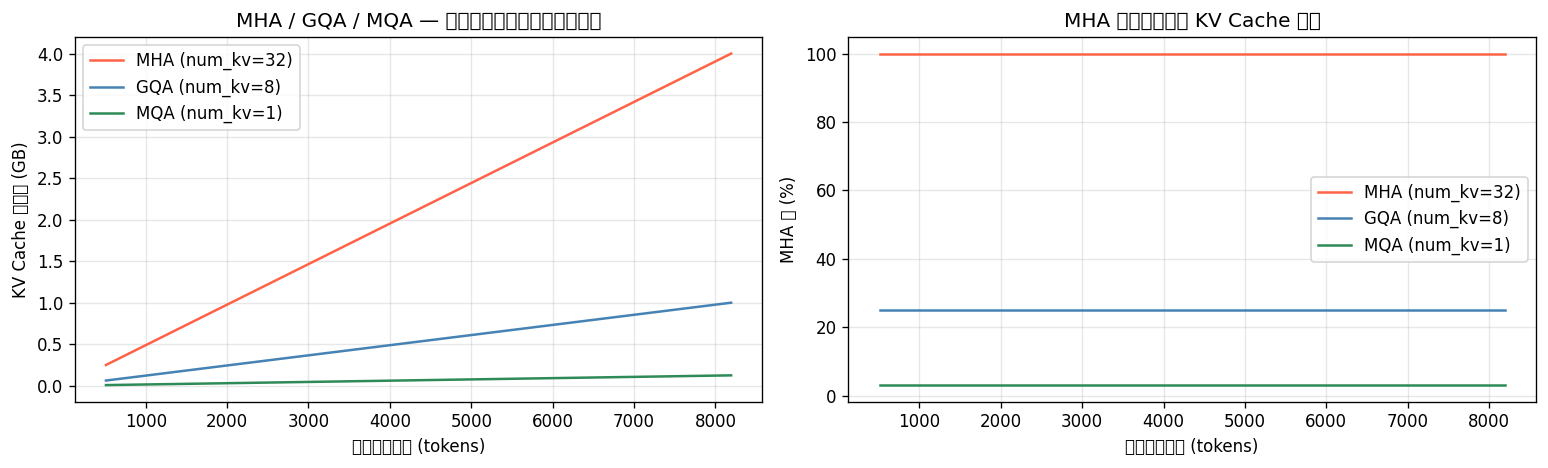

8192 tokens 時のメモリ比較 (LLaMA-3 8B 相当):
  MHA (num_kv=32)     : 4.00 GB  (100.0% of MHA)
  GQA (num_kv=8)      : 1.00 GB  (25.0% of MHA)
  MQA (num_kv=1)      : 0.12 GB  (3.1% of MHA)


In [6]:
# LLaMA-3 8B ベースのパラメータで比較
num_q_heads = 32
head_dim    = 128
num_layers  = 32
dtype_bytes = 2   # bfloat16
seq_lengths = list(range(512, 8193, 512))

def kv_bytes(seq_len, num_kv_heads):
    return 2 * seq_len * num_kv_heads * head_dim * num_layers * dtype_bytes

configs = {
    "MHA (num_kv=32)": num_q_heads,
    "GQA (num_kv=8)" : 8,
    "MQA (num_kv=1)" : 1,
}

colors = {"MHA (num_kv=32)": "tomato", "GQA (num_kv=8)": "steelblue", "MQA (num_kv=1)": "seagreen"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, n_kv in configs.items():
    mem_gb = [kv_bytes(s, n_kv) / 1024**3 for s in seq_lengths]
    axes[0].plot(seq_lengths, mem_gb, label=label, color=colors[label])

axes[0].set_xlabel("シーケンス長 (tokens)")
axes[0].set_ylabel("KV Cache メモリ (GB)")
axes[0].set_title("MHA / GQA / MQA — シーケンス長とメモリ使用量")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MHA を基準とした削減率
mha_mem = [kv_bytes(s, num_q_heads) for s in seq_lengths]
for label, n_kv in configs.items():
    ratio = [kv_bytes(s, n_kv) / mha_mem[i] for i, s in enumerate(seq_lengths)]
    axes[1].plot(seq_lengths, [r * 100 for r in ratio], label=label, color=colors[label])

axes[1].set_xlabel("シーケンス長 (tokens)")
axes[1].set_ylabel("MHA 比 (%)")
axes[1].set_title("MHA を基準とした KV Cache 比率")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"8192 tokens 時のメモリ比較 (LLaMA-3 8B 相当):")
for label, n_kv in configs.items():
    gb = kv_bytes(8192, n_kv) / 1024**3
    ratio = n_kv / num_q_heads * 100
    print(f"  {label:<20}: {gb:.2f} GB  ({ratio:.1f}% of MHA)")

---
## 5. PagedAttention ブロック管理シミュレーション

vLLM の PagedAttention は GPU メモリを **固定サイズのブロック** に分割し、  
複数リクエストが断片化なくメモリを共有できるようにする。

```
物理ブロック pool: [B0][B1][B2][B3][B4][B5]...

リクエスト A (seq_len=20, block_size=16):
  → 物理ブロック B2 (tokens 0-15), B5 (tokens 16-19)

リクエスト B (seq_len=10, block_size=16):
  → 物理ブロック B1 (tokens 0-9)
```

vLLM の `FreeKVCacheBlockQueue` は二重連結リストで O(1) 解放・取得を実現。  
各ブロックは `ref_count` を持ち、Prefix Caching でのブロック共有に利用される。

初期空きブロック数: 12/12
req A 割り当て後: 空き 9
req B 割り当て後: 空き 7
req C 割り当て後: 空き 3
req A 解放後:    空き 6
req D 割り当て後: 空き 3

操作ログ:
  alloc req=A: blocks [0, 1, 2]
  alloc req=B: blocks [3, 4]
  alloc req=C: blocks [5, 6, 7, 8]
  free  req=A: blocks [0, 1, 2] → free pool
  alloc req=D: blocks [9, 10, 11]


/tmp/ipykernel_1700968/2167312924.py:112: UserWarning: Glyph 12502 (\N{KATAKANA LETTER BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2167312924.py:112: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2167312924.py:112: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2167312924.py:112: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2167312924.py:112: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2167312924.py:112: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2167312924.py:112: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) miss

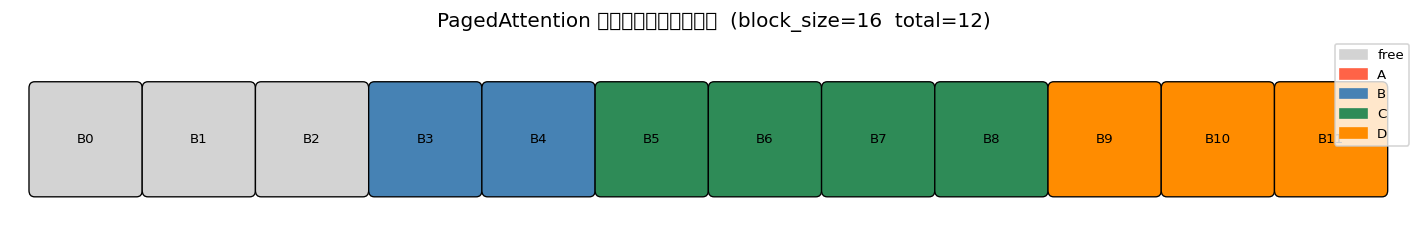

In [7]:
from collections import deque

@dataclass
class KVBlock:
    block_id: int
    ref_count: int = 0
    token_ids: list = field(default_factory=list)
    block_hash: Optional[int] = None   # Prefix Caching 用


class BlockPool:
    """vLLM KVCacheBlock / FreeKVCacheBlockQueue の簡易シミュレーション"""

    def __init__(self, num_blocks: int, block_size: int):
        self.block_size = block_size
        self.blocks = [KVBlock(i) for i in range(num_blocks)]
        # 空きブロックキュー（FIFO; vLLM 実装は doubly-linked list で O(1)）
        self.free_queue: deque[KVBlock] = deque(self.blocks)
        self.hash_to_block: dict[int, KVBlock] = {}   # Prefix Caching 用
        self.log = []

    def allocate(self, req_id: str, token_ids: list) -> list[KVBlock]:
        needed = (len(token_ids) + self.block_size - 1) // self.block_size
        if len(self.free_queue) < needed:
            raise MemoryError(f"OOM: need {needed} blocks, have {len(self.free_queue)}")
        allocated = []
        for i in range(needed):
            blk = self.free_queue.popleft()
            start = i * self.block_size
            blk.token_ids = token_ids[start:start + self.block_size]
            blk.ref_count = 1
            allocated.append(blk)
        self.log.append(f"alloc req={req_id}: blocks {[b.block_id for b in allocated]}")
        return allocated

    def free(self, req_id: str, blocks: list[KVBlock]):
        freed_ids = []
        for blk in blocks:
            blk.ref_count -= 1
            if blk.ref_count == 0:
                blk.token_ids = []
                blk.block_hash = None
                self.free_queue.append(blk)
                freed_ids.append(blk.block_id)
        self.log.append(f"free  req={req_id}: blocks {freed_ids} → free pool")

    @property
    def free_count(self):
        return len(self.free_queue)


# --- シミュレーション ---
TOTAL_BLOCKS = 12
BLOCK_SIZE   = 16

pool = BlockPool(TOTAL_BLOCKS, BLOCK_SIZE)
print(f"初期空きブロック数: {pool.free_count}/{TOTAL_BLOCKS}")

# リクエスト A: 40 tokens → 3 blocks
req_a_tokens = list(range(40))
blks_a = pool.allocate("A", req_a_tokens)
print(f"req A 割り当て後: 空き {pool.free_count}")

# リクエスト B: 20 tokens → 2 blocks
req_b_tokens = list(range(100, 120))
blks_b = pool.allocate("B", req_b_tokens)
print(f"req B 割り当て後: 空き {pool.free_count}")

# リクエスト C: 64 tokens → 4 blocks
req_c_tokens = list(range(200, 264))
blks_c = pool.allocate("C", req_c_tokens)
print(f"req C 割り当て後: 空き {pool.free_count}")

# req A 完了 → 解放
pool.free("A", blks_a)
print(f"req A 解放後:    空き {pool.free_count}")

# 解放されたブロックに新リクエスト D を割り当て
req_d_tokens = list(range(300, 348))
blks_d = pool.allocate("D", req_d_tokens)
print(f"req D 割り当て後: 空き {pool.free_count}")

print()
print("操作ログ:")
for entry in pool.log:
    print(" ", entry)

# --- ブロック使用状況の可視化 ---
# 各ブロックの状態をヒートマップ風に表示
all_reqs = {"A": blks_a, "B": blks_b, "C": blks_c, "D": blks_d}
state = ["free"] * TOTAL_BLOCKS
for req, blks in all_reqs.items():
    for b in blks:
        if b.ref_count > 0:
            state[b.block_id] = req

fig, ax = plt.subplots(figsize=(12, 2))
color_map = {"free": "lightgray", "A": "tomato", "B": "steelblue", "C": "seagreen", "D": "darkorange"}
for i, s in enumerate(state):
    rect = mpatches.FancyBboxPatch((i, 0), 0.9, 0.8,
                                   boxstyle="round,pad=0.05",
                                   facecolor=color_map[s], edgecolor="black", linewidth=0.8)
    ax.add_patch(rect)
    ax.text(i + 0.45, 0.4, f"B{i}", ha="center", va="center", fontsize=8)

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_handles, loc="upper right", fontsize=8)
ax.set_xlim(-0.2, TOTAL_BLOCKS + 0.2)
ax.set_ylim(-0.2, 1.2)
ax.axis("off")
ax.set_title(f"PagedAttention ブロック割り当て状況  (block_size={BLOCK_SIZE}  total={TOTAL_BLOCKS})")
plt.tight_layout()
plt.show()

---
## 6. Prefix Caching ハッシュチェーン

vLLM の Prefix Caching では、**ブロック単位で KV を再利用**する。  
同一のプレフィックス（system prompt など）を持つリクエストは、  
すでにキャッシュされたブロックを `ref_count++` するだけで再計算不要になる。

ブロックのハッシュは **チェーン方式**：
```python
# vLLM: kv_cache_utils.py  hash_block_tokens()
block_hash = hash((parent_block_hash, tuple(token_ids), extra_keys))
```

これにより、同一プレフィックスのブロックは同一ハッシュ値になり、  
異なるリクエストで **物理ブロックを共有** できる。

=== リクエスト A のブロックハッシュ ===
  Block 0: tokens=(1, 2, 3, 4)  hash=ab91...
  Block 1: tokens=(5, 6, 7, 8)  hash=a027...
  Block 2: tokens=(9, 10, 11, 12)  hash=41bf...
  Block 3: tokens=(101, 102, 103, 104)  hash=a617...

=== リクエスト B のブロックハッシュ ===
  Block 0: tokens=(1, 2, 3, 4)  hash=ab91...
  Block 1: tokens=(5, 6, 7, 8)  hash=a027...
  Block 2: tokens=(9, 10, 11, 12)  hash=41bf...
  Block 3: tokens=(201, 202, 203, 204)  hash=b4d9...

共有できるブロック数: 3 / 4
  → system prompt 12 tokens (3 blocks) を KV 再利用可能
  → user prompt ブロックは別内容なのでハッシュ不一致 → 再計算必要


/tmp/ipykernel_1700968/2811274905.py:77: UserWarning: Glyph 12502 (\N{KATAKANA LETTER BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2811274905.py:77: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2811274905.py:77: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2811274905.py:77: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2811274905.py:77: UserWarning: Glyph 12495 (\N{KATAKANA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2811274905.py:77: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/2811274905.py:77: UserWarning: Glyph 12517 (\N{KATAKANA LETTER SMALL YU}) missing from font(s) 

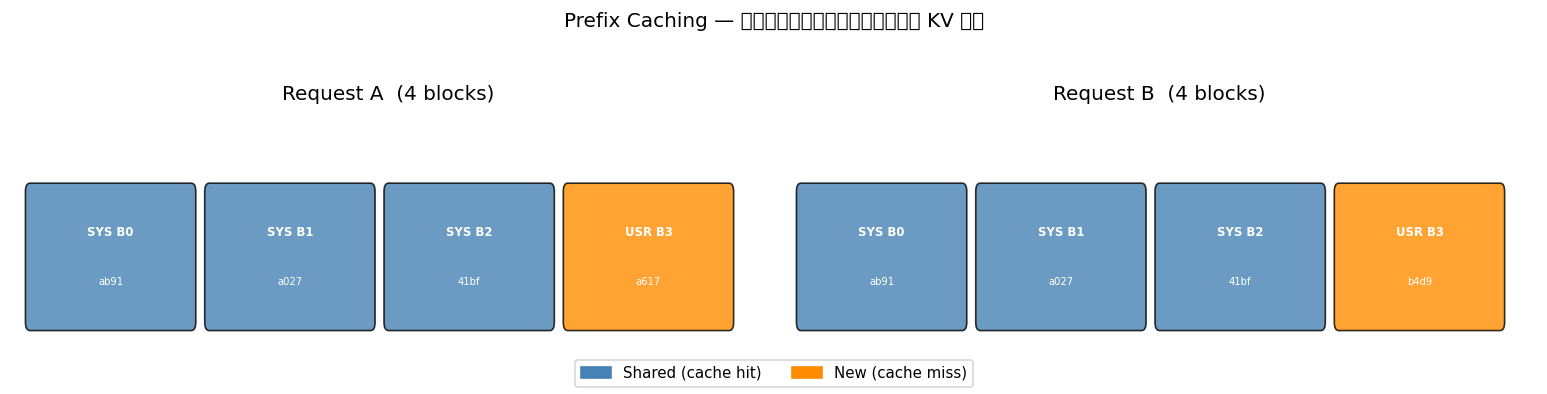

In [8]:
def hash_block_tokens(parent_hash: int, token_ids: tuple, extra_keys: tuple = ()) -> int:
    """vLLM hash_block_tokens() の模倣（実装は hashlib を使用）"""
    h = hashlib.sha256()
    h.update(str((parent_hash, token_ids, extra_keys)).encode())
    return int(h.hexdigest()[:16], 16)  # 64bit に切り詰め


BLOCK_SIZE = 4   # 説明のため小さめ
INIT_HASH  = 0   # root ブロックの親ハッシュ

def compute_prefix_hashes(token_ids: list[int], block_size: int = BLOCK_SIZE) -> list[dict]:
    """トークン列をブロックに分割し、各ブロックのチェーンハッシュを計算"""
    blocks = []
    parent_hash = INIT_HASH
    for start in range(0, len(token_ids), block_size):
        chunk = tuple(token_ids[start:start + block_size])
        if len(chunk) < block_size:
            break  # 最後の不完全ブロックはキャッシュ対象外（vLLM 仕様）
        bh = hash_block_tokens(parent_hash, chunk)
        blocks.append({"tokens": chunk, "parent_hash": parent_hash, "block_hash": bh})
        parent_hash = bh
    return blocks


# system prompt (共通) + 独自 user prompt を持つ 2 リクエスト
SYSTEM_TOKENS = [1, 2, 3, 4,  5, 6, 7, 8,  9, 10, 11, 12]  # 12 tokens = 3 blocks
USER_A_TOKENS = [101, 102, 103, 104]                          # 1 block
USER_B_TOKENS = [201, 202, 203, 204]                          # 1 block (別内容)

tokens_A = SYSTEM_TOKENS + USER_A_TOKENS
tokens_B = SYSTEM_TOKENS + USER_B_TOKENS

hashes_A = compute_prefix_hashes(tokens_A)
hashes_B = compute_prefix_hashes(tokens_B)

print("=== リクエスト A のブロックハッシュ ===")
for i, b in enumerate(hashes_A):
    print(f"  Block {i}: tokens={b['tokens']}  hash={b['block_hash'] & 0xFFFF:04x}...")

print()
print("=== リクエスト B のブロックハッシュ ===")
for i, b in enumerate(hashes_B):
    print(f"  Block {i}: tokens={b['tokens']}  hash={b['block_hash'] & 0xFFFF:04x}...")

# ハッシュ一致チェック
print()
shared = sum(1 for a, b in zip(hashes_A, hashes_B) if a["block_hash"] == b["block_hash"])
print(f"共有できるブロック数: {shared} / {max(len(hashes_A), len(hashes_B))}")
print(f"  → system prompt {len(SYSTEM_TOKENS)} tokens ({shared} blocks) を KV 再利用可能")
print(f"  → user prompt ブロックは別内容なのでハッシュ不一致 → 再計算必要")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 3))

for ax, hashes, label in [(axes[0], hashes_A, "Request A"), (axes[1], hashes_B, "Request B")]:
    for i, b in enumerate(hashes):
        is_shared = (i < shared)
        color = "steelblue" if is_shared else "darkorange"
        rect = mpatches.FancyBboxPatch((i * 2, 0), 1.8, 0.8,
                                       boxstyle="round,pad=0.05",
                                       facecolor=color, edgecolor="black", alpha=0.8)
        ax.add_patch(rect)
        tag = "SYS" if is_shared else "USR"
        ax.text(i * 2 + 0.9, 0.55, f"{tag} B{i}", ha="center", va="center",
                fontsize=7, color="white", fontweight="bold")
        ax.text(i * 2 + 0.9, 0.25, f"{b['block_hash'] & 0xFFFF:04x}", ha="center",
                va="center", fontsize=6, color="white")
    ax.set_xlim(-0.2, len(hashes) * 2 + 0.2)
    ax.set_ylim(-0.3, 1.3)
    ax.axis("off")
    ax.set_title(f"{label}  ({len(hashes)} blocks)")

shared_patch  = mpatches.Patch(color="steelblue",  label="Shared (cache hit)")
new_patch     = mpatches.Patch(color="darkorange", label="New (cache miss)")
fig.legend(handles=[shared_patch, new_patch], loc="lower center", ncol=2, fontsize=9)
plt.suptitle("Prefix Caching — ブロックハッシュチェーンによる KV 共有", y=1.05)
plt.tight_layout()
plt.show()

---
## 7. KV Cache 量子化の効果

vLLM の `KVQuantMode` が対応する量子化方式：

| モード | dtype | 精度 | メモリ削減率 |
|---|---|---|---|
| NONE | bfloat16 / float16 | 基準 | 1x |
| FP8_PER_TENSOR | FP8 E4M3 | ほぼ同等 | **2x** |
| INT8_PER_TOKEN_HEAD | INT8 + scale | わずかな劣化 | **2x** |
| NVFP4 | FP4 E2M1 | 実験的 | **4x** |

transformers の `QuantizedCache` (KIVI アルゴリズム) は異なるアプローチ：
- 古いトークン → 4bit 圧縮
- 直近 `residual_length=128` トークン → 16bit のまま（Attention 精度を維持）

方式                           RMSE     メモリ (KB)      削減率
----------------------------------------------------------
FP16 (baseline)                 —         64.0     1.0x
FP8 (per-tensor)         0.316075         32.0      2.0x
INT8 (per-token)         0.006481         33.0      1.9x
KIVI (res=32)            0.006066         44.0      1.5x


/tmp/ipykernel_1700968/3450966612.py:108: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/3450966612.py:108: UserWarning: Glyph 12373 (\N{HIRAGANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/3450966612.py:108: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/3450966612.py:108: UserWarning: Glyph 12411 (\N{HIRAGANA LETTER HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/3450966612.py:108: UserWarning: Glyph 12393 (\N{HIRAGANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/3450966612.py:108: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1700968/3450966612.py:108: UserWarning: Glyph 31934 (\N{CJK UNIFIED IDEOGRAPH-7CBE}) mis

/home/jetson/venv/notebook/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jetson/venv/notebook/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12373 (\N{HIRAGANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jetson/venv/notebook/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jetson/venv/notebook/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12411 (\N{HIRAGANA LETTER HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jetson/venv/notebook/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12393 (\N{HIRAGANA LETTER DO})

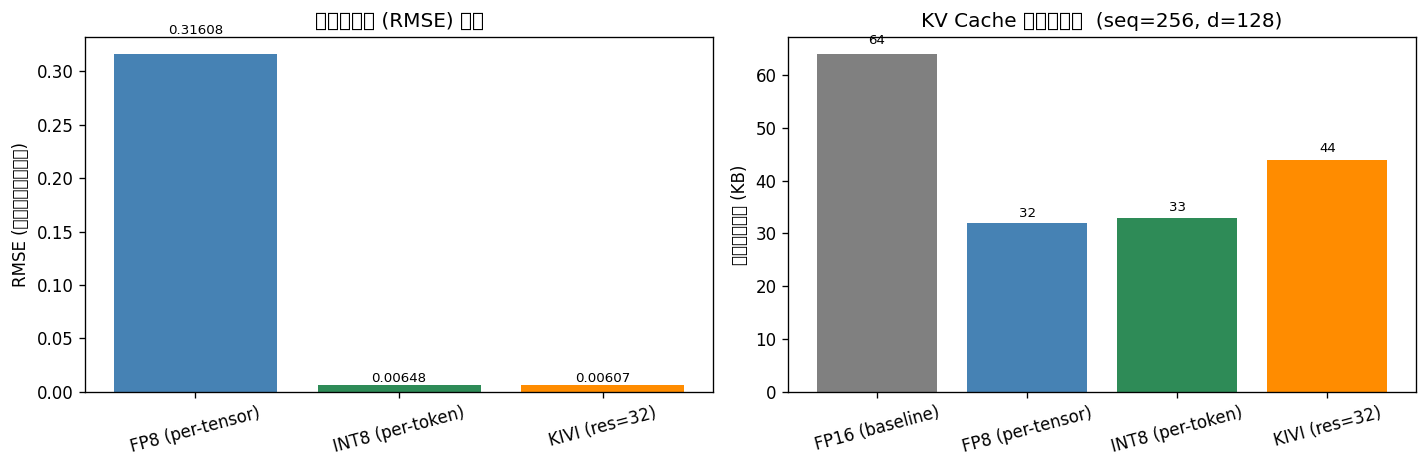

In [9]:
def quantize_fp8(x: np.ndarray) -> tuple[np.ndarray, float]:
    """FP8 E4M3 の簡易シミュレーション（スケール × 8bit 整数で近似）"""
    scale = np.abs(x).max() / 448.0 + 1e-12   # E4M3 max = 448
    x_q   = np.clip(np.round(x / scale), -128, 127).astype(np.int8)
    return x_q, scale

def dequantize_fp8(x_q: np.ndarray, scale: float) -> np.ndarray:
    return x_q.astype(np.float32) * scale

def quantize_int8_per_token(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """INT8 per-token: 各行（トークン）ごとにスケーリング"""
    scales = np.abs(x).max(axis=-1, keepdims=True) / 127.0 + 1e-12
    x_q    = np.clip(np.round(x / scales), -128, 127).astype(np.int8)
    return x_q, scales

def dequantize_int8_per_token(x_q: np.ndarray, scales: np.ndarray) -> np.ndarray:
    return x_q.astype(np.float32) * scales

def kivi_quantize(cache: np.ndarray, residual_length: int = 16):
    """KIVI: 直近 residual_length トークンは fp32 のまま、それ以外は int8 圧縮"""
    if len(cache) <= residual_length:
        return cache.astype(np.float32), None, None
    old   = cache[:-residual_length]
    recent= cache[-residual_length:]
    scales = np.abs(old).max(axis=-1, keepdims=True) / 127.0 + 1e-12
    old_q  = np.clip(np.round(old / scales), -128, 127).astype(np.int8)
    return recent.astype(np.float32), old_q, scales

def kivi_dequantize(recent, old_q, scales):
    if old_q is None:
        return recent
    old_deq = old_q.astype(np.float32) * scales
    return np.vstack([old_deq, recent])


# --- 量子化誤差とメモリ削減のシミュレーション ---
np.random.seed(7)
SEQ, D = 256, 128
cache_fp16 = np.random.randn(SEQ, D).astype(np.float16)

# FP8
fp8_q, fp8_scale = quantize_fp8(cache_fp16.astype(np.float32))
fp8_deq = dequantize_fp8(fp8_q, fp8_scale)

# INT8 per-token
int8_q, int8_scales = quantize_int8_per_token(cache_fp16.astype(np.float32))
int8_deq = dequantize_int8_per_token(int8_q, int8_scales)

# KIVI (residual_length=32)
RESIDUAL = 32
recent, old_q, old_scales = kivi_quantize(cache_fp16.astype(np.float32), RESIDUAL)
kivi_deq = kivi_dequantize(recent, old_q, old_scales)

# 誤差計算
def rmse(a, b):
    return np.sqrt(np.mean((a.astype(np.float32) - b) ** 2))

orig = cache_fp16.astype(np.float32)
errors = {
    "FP8 (per-tensor)":   rmse(orig, fp8_deq),
    "INT8 (per-token)":   rmse(orig, int8_deq),
    f"KIVI (res={RESIDUAL})": rmse(orig, kivi_deq),
}

# メモリ削減率（FP16 ベースライン = 2 bytes/element）
baseline_bytes = SEQ * D * 2
memory = {
    "FP16 (baseline)":    baseline_bytes,
    "FP8 (per-tensor)":   SEQ * D * 1,           # 1 byte/elem
    "INT8 (per-token)":   SEQ * D * 1 + SEQ * 4, # int8 + per-token scale (float32)
    f"KIVI (res={RESIDUAL})": (SEQ - RESIDUAL) * D * 1 + RESIDUAL * D * 4,
}

print(f"{'方式':<22} {'RMSE':>10} {'メモリ (KB)':>12} {'削減率':>8}")
print("-" * 58)
print(f"{'FP16 (baseline)':<22} {'—':>10} {baseline_bytes/1024:>12.1f} {'1.0x':>8}")
for name, err in errors.items():
    mem = memory[name]
    ratio = baseline_bytes / mem
    print(f"{name:<22} {err:>10.6f} {mem/1024:>12.1f} {ratio:>8.1f}x")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RMSE 棒グラフ
names  = list(errors.keys())
values = list(errors.values())
bars = axes[0].bar(names, values, color=["steelblue", "seagreen", "darkorange"])
axes[0].set_ylabel("RMSE (小さいほど高精度)")
axes[0].set_title("量子化誤差 (RMSE) 比較")
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v * 1.05, f"{v:.5f}",
                 ha="center", va="bottom", fontsize=8)

# メモリ削減率棒グラフ
all_names = list(memory.keys())
all_mem   = [m / 1024 for m in memory.values()]
colors    = ["gray", "steelblue", "seagreen", "darkorange"]
bars2 = axes[1].bar(all_names, all_mem, color=colors)
axes[1].set_ylabel("メモリ使用量 (KB)")
axes[1].set_title(f"KV Cache メモリ比較  (seq={SEQ}, d={D})")
axes[1].tick_params(axis='x', rotation=15)
for bar, m in zip(bars2, all_mem):
    axes[1].text(bar.get_x() + bar.get_width()/2, m * 1.02, f"{m:.0f}",
                 ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()